Part 2:

Use the cifar100 dataset included with keras and repeat the experiment in Part 2.

In [10]:
import keras

# load the cifar100 dataset from keras
(x_train100, y_train100), (x_test100, y_test100) = keras.datasets.cifar100.load_data(label_mode='fine')
assert x_train100.shape == (50000, 32, 32, 3)
assert x_test100.shape == (10000, 32, 32, 3)
assert y_train100.shape == (50000, 1)
assert y_test100.shape == (10000, 1)

In [11]:
# Normalize pixel values to be between 0 and 1
x_train100, x_test100 = x_train100 / 255.0, x_test100 / 255.0

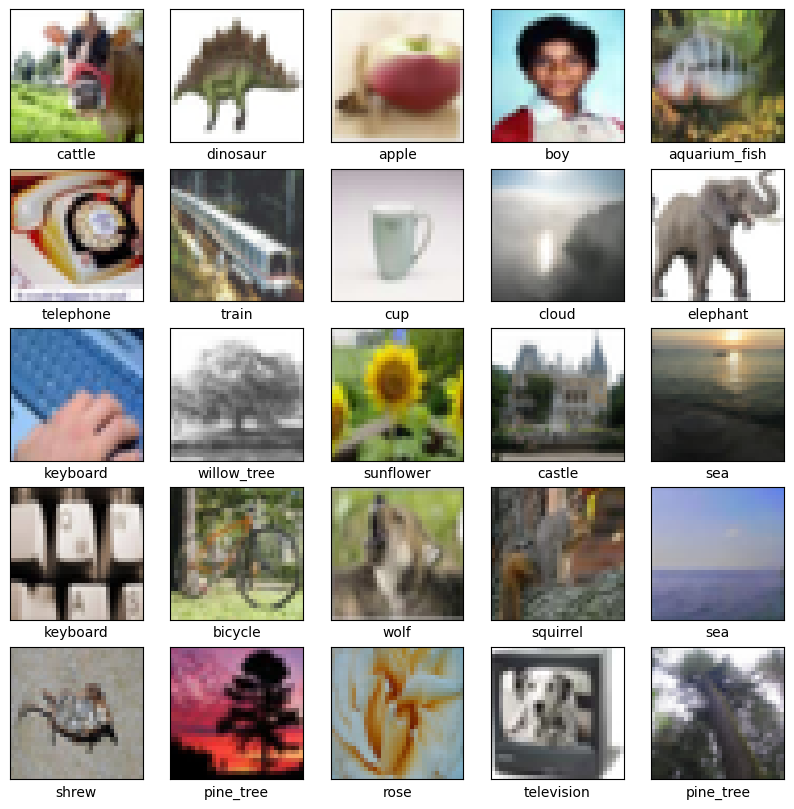

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# visualize some of the data
class_names100 = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe',
    'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train100[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names100[y_train100[i][0]])
plt.show()

In [26]:
from keras import datasets, layers, models

# construct a CNN to predict the image labels
model100 = models.Sequential()
model100.add(layers.InputLayer((32, 32, 3)))
#model100.add(layers.RandomRotation(0.1))
#model100.add(layers.RandomTranslation(0.1, 0.1))

# added the convolutional layers
model100.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model100.add(layers.BatchNormalization())
model100.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model100.add(layers.BatchNormalization())
model100.add(layers.MaxPooling2D())

model100.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model100.add(layers.BatchNormalization())
model100.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model100.add(layers.BatchNormalization())
model100.add(layers.MaxPooling2D())

model100.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model100.add(layers.BatchNormalization())
model100.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model100.add(layers.BatchNormalization())
model100.add(layers.MaxPooling2D())

# flatten
model100.add(layers.Flatten())

# fully connected layers
model100.add(layers.Dense(256, activation='relu'))
model100.add(layers.Dropout(0.2))
model100.add(layers.Dense(100))

In [27]:
# display the model
model100.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,223,524 (8.48 MB)

 Trainable params: 2,221,732 (8.48 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [28]:
# compile the model
model100.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [29]:
# train the model
history100 = model100.fit(x_train100, y_train100, epochs=15, validation_data=(x_test100, y_test100))

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.0403 - loss: 4.4413 - val_accuracy: 0.1041 - val_loss: 3.8121
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0865 - loss: 3.8800 - val_accuracy: 0.1584 - val_loss: 3.4888
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.1450 - loss: 3.4806 - val_accuracy: 0.2481 - val_loss: 2.9455
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.2039 - loss: 3.1411 - val_accuracy: 0.2358 - val_loss: 3.1044
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.2636 - loss: 2.8215 - val_accuracy: 0.3276 - val_loss: 2.6354
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3414 - loss: 2.4708 - val_accuracy: 0.4101 - val_loss: 2.2168
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4199 - loss: 2.1264 - val_accuracy: 0.4398 - val_loss: 2.1119
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4846 -

In [30]:
model100.save("/content/Prg2_Part2.keras")

313/313 - 2s - 5ms/step - accuracy: 0.5127 - loss: 2.3515


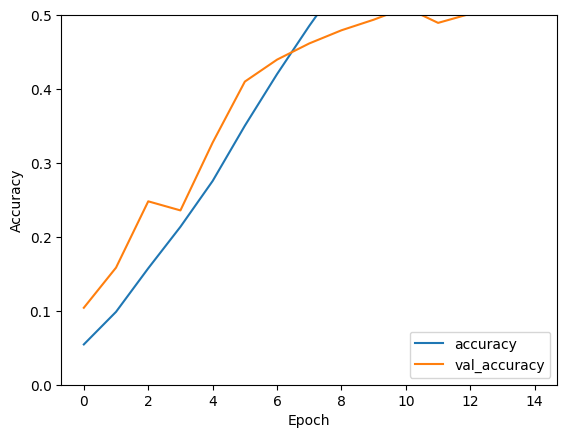

In [31]:
# evaluate the model's accuracy
plt.plot(history100.history['accuracy'], label='accuracy')
plt.plot(history100.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 0.5])
plt.legend(loc='lower right')

test_loss100, test_acc100 = model100.evaluate(x_test100,  y_test100, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


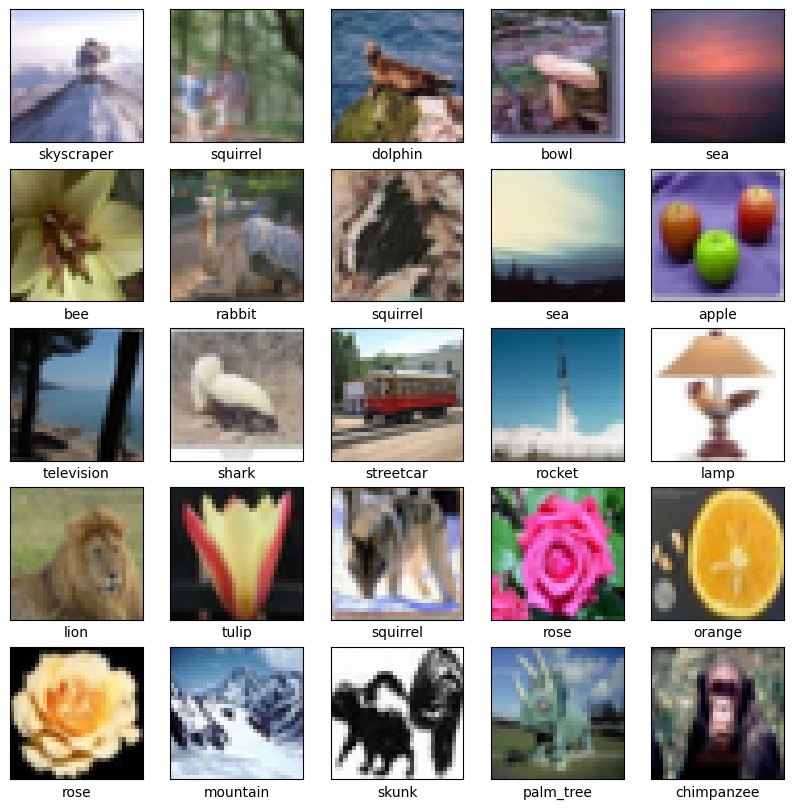

In [32]:
# visualize predictions
predictions100 = model100.predict(x_test100)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test100[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names100[np.argmax(predictions100[i, :])])
plt.show()